In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
trades=pd.read_csv("historical_data.csv")
trades.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
sentiments=pd.read_csv('fear_greed_index.csv')
sentiments.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print(trades.shape)
print(sentiments.shape)
trades.info()
sentiments.info()

(211224, 16)
(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dt

In [5]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
sentiments.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
trades.duplicated().sum()
sentiments.duplicated().sum()

0

# Convert Timestamp and Allign the dataset by date

In [8]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date
sentiments['date'] = pd.to_datetime(sentiments['date']).dt.date

In [9]:
print(trades.columns.tolist())
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']


In [10]:
trades['win'] = trades['closed_pnl'] > 0

In [11]:
daily = trades.groupby(['date', 'account']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'trade_id': 'count',
    'win': 'mean',
}).reset_index()

In [12]:
daily.rename(columns={
    'account': 'trader_id',
    'closed_pnl': 'daily_pnl',
    'size_usd': 'avg_trade_size',
    'trade_id': 'num_trades',
    'win': 'win_rate'
}, inplace=True)

In [13]:
trades['leverage'] = 1  # placeholder

In [14]:
trades['side'] = trades['closed_pnl'].apply(lambda x: 'long' if x > 0 else 'short')

In [15]:
long_ratio = trades.groupby(['date', 'account'])['side'].apply(
    lambda x: (x == 'BUY').sum() / len(x)
).reset_index()

long_ratio.rename(columns={'account': 'trader_id', 'side': 'long_ratio'}, inplace=True)

# Merge long_ratio
daily = pd.merge(daily, long_ratio, on=['date', 'trader_id'])

In [16]:
data = pd.merge(daily, sentiments, on='date', how='inner')
print("Merged Successfully!!!")

Merged Successfully!!!


In [17]:
data['sentiment_label'] = data['value'].apply(
    lambda x: 'Fear' if x < 50 else 'Greed'
)

In [18]:
data = data.sort_values(['trader_id', 'date'])

In [19]:
data['drawdown_proxy'] = data.groupby('trader_id')['daily_pnl'] \
    .rolling(5).min().reset_index(0, drop=True)

In [20]:
perf = data.groupby('sentiment_label')[
    ['daily_pnl', 'win_rate', 'drawdown_proxy']
].mean()

print(perf)

                   daily_pnl  win_rate  drawdown_proxy
sentiment_label                                       
Fear             4949.971244  0.360563    -3837.439913
Greed            3933.562857  0.358934    -3832.687116


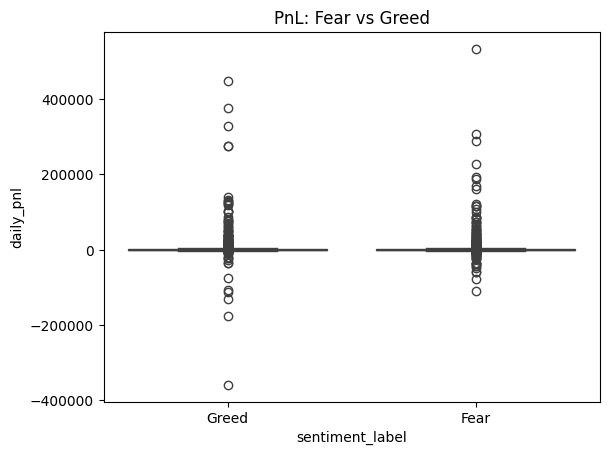

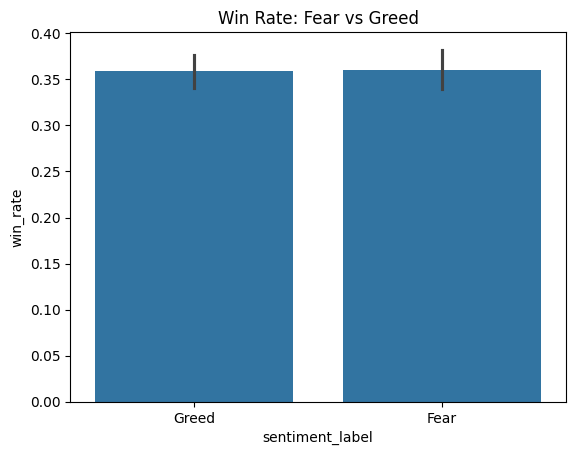

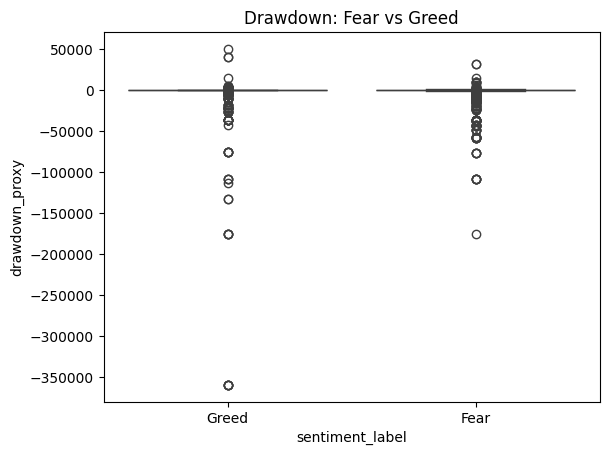

In [21]:
sns.boxplot(x='sentiment_label', y='daily_pnl', data=data)
plt.title("PnL: Fear vs Greed")
plt.show()

sns.barplot(x='sentiment_label', y='win_rate', data=data)
plt.title("Win Rate: Fear vs Greed")
plt.show()

sns.boxplot(x='sentiment_label', y='drawdown_proxy', data=data)
plt.title("Drawdown: Fear vs Greed")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data['profit_flag'] = data['daily_pnl'] > 0

X = data[[ 'num_trades', 'long_ratio', 'value']]
y = data['profit_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
data['cluster'] = kmeans.fit_predict(X)

In [24]:
mkdir outputs

A subdirectory or file outputs already exists.


In [25]:
import os
os.makedirs("outputs", exist_ok=True)

In [26]:
plt.figure()
sns.boxplot(x='sentiment_label', y='daily_pnl', data=data)
plt.title("PnL: Fear vs Greed")
plt.savefig("outputs/pnl_chart.png")
plt.close()

In [27]:
plt.figure()
sns.barplot(x='sentiment_label', y='win_rate', data=data)
plt.title("Win Rate: Fear vs Greed")
plt.savefig("outputs/winrate_chart.png")
plt.close()

In [28]:
plt.figure()
sns.boxplot(x='sentiment_label', y='drawdown_proxy', data=data)
plt.title("Drawdown: Fear vs Greed")
plt.savefig("outputs/drawdown_chart.png")
plt.close()